In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/superstore-usadataset/Superstore_USA.xlsx


#                                                      ECOMMERCE DATA ANALYSIS

In [40]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [41]:
dataset = pd.read_excel("//kaggle/input/superstore-usadataset/Superstore_USA.xlsx")

In [42]:
dataset.isnull().sum()


Row ID                   0
Order Priority           0
Discount                 0
Unit Price               0
Shipping Cost            0
Customer ID              0
Customer Name            0
Ship Mode                0
Customer Segment         0
Product Category         0
Product Sub-Category     0
Product Container        0
Product Name             0
Product Base Margin     72
Region                   0
State or Province        0
City                     0
Postal Code              0
Order Date               0
Ship Date                0
Profit                   0
Quantity ordered new     0
Sales                    0
Order ID                 0
dtype: int64

In [43]:
dataset.head()

,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Region,State or Province,City,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
0,18606,Not Specified,0.01,2.88,0.50,2,Janice Fletcher,Regular Air,Corporate,Office Supplies,...,Central,Illinois,Addison,60101,2012-05-28,2012-05-30,1.3200,2,5.90,88525
1,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2010-07-07,2010-07-08,4.5600,4,13.01,88522
2,23086,Not Specified,0.03,6.68,6.15,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2011-07-27,2011-07-28,-47.6400,7,49.92,88523
3,23087,Not Specified,0.01,5.68,3.60,3,Bonnie Potter,Regular Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2011-07-27,2011-07-28,-30.5100,7,41.64,88523
4,23088,Not Specified,0.00,205.99,2.50,3,Bonnie Potter,Express Air,Corporate,Technology,...,West,Washington,Anacortes,98221,2011-07-27,2011-07-27,998.2023,8,1446.67,88523


In [44]:
dataset['Product Base Margin'] = dataset['Product Base Margin'].fillna(dataset['Product Base Margin'].mean())

In [45]:
dataset['Order Priority'].value_counts()

Order Priority
High             1970
Low              1926
Not Specified    1881
Medium           1844
Critical         1804
Critical            1
Name: count, dtype: int64

In [46]:
#dataset['Order Priority'].unique()

# ORDER PRIORITY

In [47]:
dataset['Order Priority'] = dataset['Order Priority'].replace("Critical ","Critical")

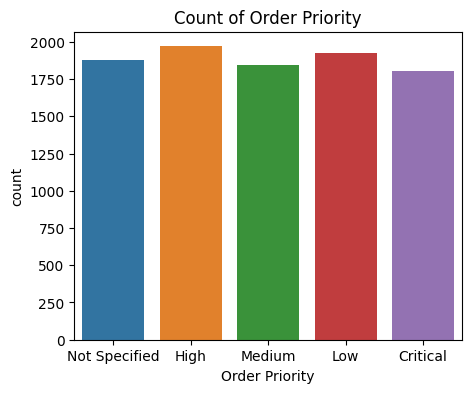

In [48]:
plt.figure(figsize =(5,4))
sns.countplot(x="Order Priority",data=dataset)
plt.title("Count of Order Priority")
plt.savefig("Count of Order Priority.jpg") #for save the graph
plt.show()

Order Priority
High             1970
Low              1926
Not Specified    1881
Medium           1844
Critical         1805
Name: count, dtype: int64


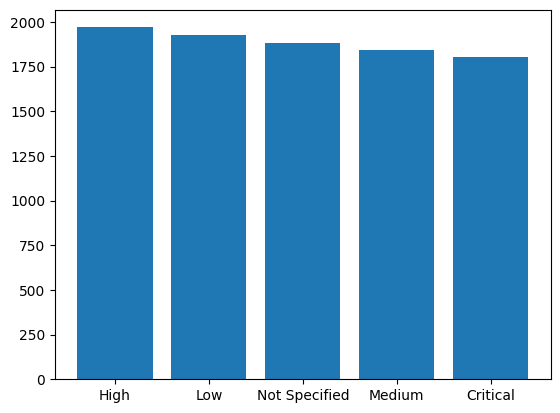

In [49]:
k = dataset["Order Priority"].value_counts()
print(k)
x = np.array(k.index)
y = np.array(k.values)

plt.bar(x,y)
plt.show()



# SHIP MODE

In [50]:
dataset['Ship Mode'].value_counts()

Ship Mode
Regular Air       7036
Delivery Truck    1283
Express Air       1107
Name: count, dtype: int64

In [51]:
x = dataset['Ship Mode'].value_counts().index
y = dataset['Ship Mode'].value_counts().values

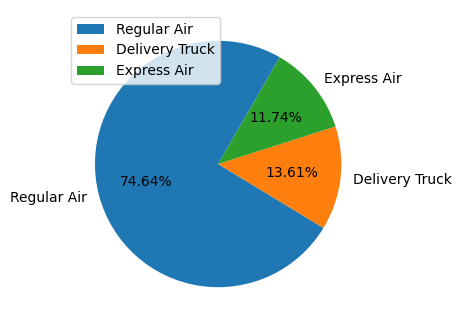

In [52]:
plt.figure(figsize=(5,4))
plt.pie(y,labels=x,startangle=60,autopct="%0.2f%%")
plt.legend(loc=2)
plt.show()

# SHIP MODE


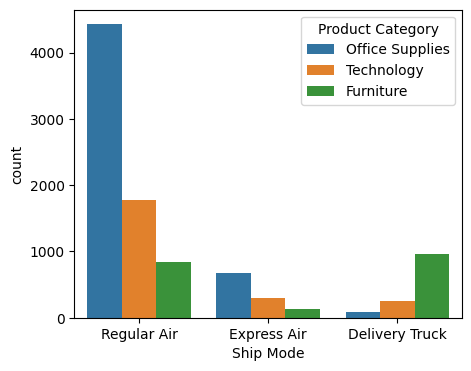

In [53]:
plt.figure(figsize=(5,4))
sns.countplot(x="Ship Mode",data= dataset,hue="Product Category") #hue use to add multiple dataset
plt.show()

# CUSTOMER SEGEMENT

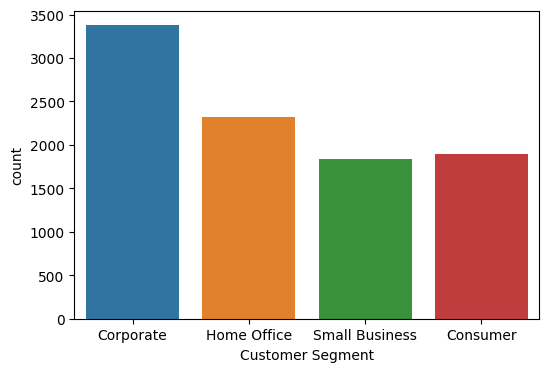

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(x="Customer Segment",data=dataset)
plt.show()

# PRODUCT CATEGORY

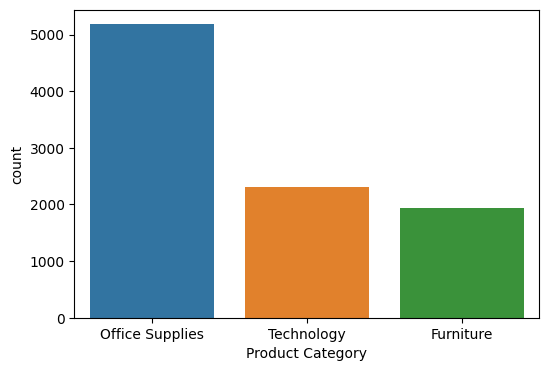

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x="Product Category",data=dataset)
plt.show()

# PRODUCT SUB-CATEGORY

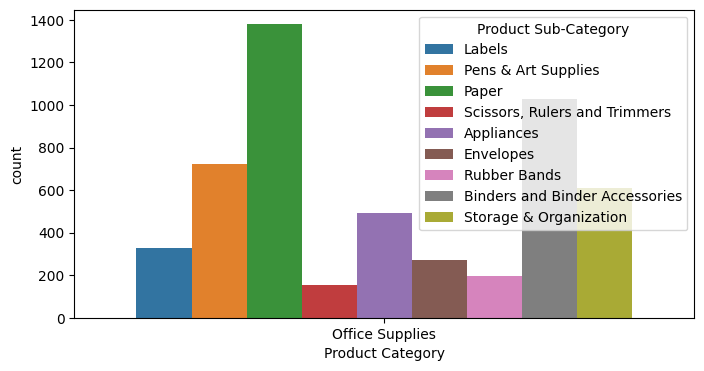

In [56]:
plt.figure(figsize=(8,4))
sns.countplot(x="Product Category",data=dataset[dataset["Product Category"]=="Office Supplies"],hue="Product Sub-Category") 
plt.show()

# ORDER YEAR

In [57]:
dataset["Order Year"] = dataset["Order Date"].dt.year

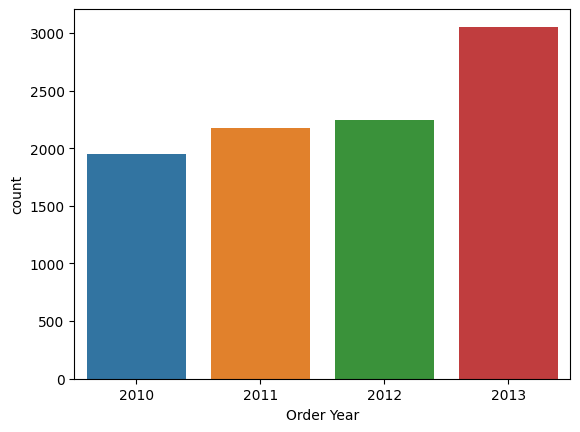

In [58]:
dataset["Order Year"].value_counts()
sns.countplot(x="Order Year",data=dataset)
plt.show()

# PROFIT

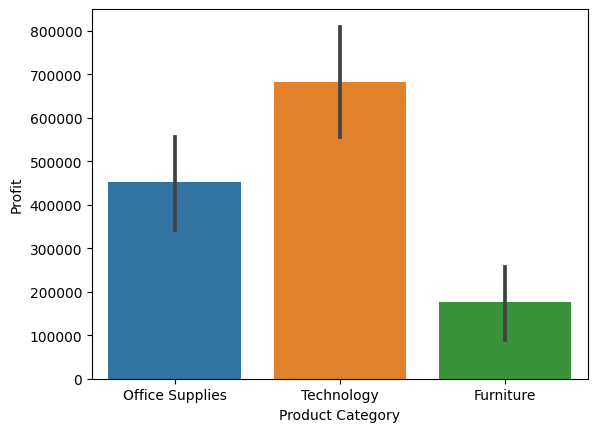

In [59]:
sns.barplot(x="Product Category",y="Profit",data=dataset,estimator= "sum") #profit of sum
plt.show()


# STATE OR PROVINCE SELLS

In [60]:
dataset['State or Province'].value_counts()[:5] #top 5 sell data

State or Province
California    1021
Texas          646
Illinois       584
New York       574
Florida        522
Name: count, dtype: int64

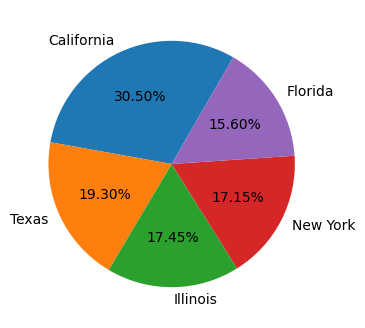

In [61]:
plt.figure(figsize=(6,4))
x = dataset['State or Province'].value_counts().index[:5]
y = dataset['State or Province'].value_counts().values[:5]
plt.pie(y,labels=x,startangle=60,autopct="%0.2f%%")
plt.show()
#top 5 state wise sell